# Graph Mining
## Lab 5: Heat Diffusion

In this lab, you will learn to use heat diffusion for **contrastive ranking** and **node classification**.

## Import

In [1]:
!pip install scikit-network

In [2]:
from IPython.display import SVG

In [3]:
import numpy as np
from scipy import sparse

In [4]:
from sknetwork.data import load_netset, grid, karate_club
from sknetwork.regression import Dirichlet
from sknetwork.classification import DiffusionClassifier, get_accuracy_score
from sknetwork.ranking import PageRank
from sknetwork.utils import directed2undirected
from sknetwork.visualization import visualize_graph

## Data

We will work on the following graphs (see the [NetSet](https://netset.telecom-paris.fr/) collection for details):
* Openflights (graph)
* WikiVitals (directed graph + bipartite graph)

In [5]:
openflights = load_netset('openflights')
wikivitals = load_netset('wikivitals')

Parsing files...
Done.
Parsing files...
Done.


## 1. Graphs

## Grid

We first illustrate the notion of **contrastive ranking** on a $k\times k$ grid.

In [6]:
k = 5
dataset = grid(k, k, True)
adjacency = dataset.adjacency
position = dataset.position

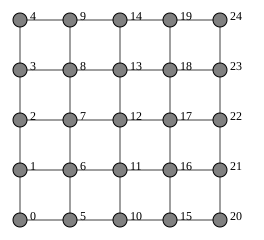

In [7]:
image = visualize_graph(adjacency, position, names=np.arange(k * k), width=200, height=200)
SVG(image)

## To do

* Display the solution to the Dirichlet problem with 1 hot source and 1 cold source, located on the opposite corners of the square.
* Add a hot source at the top-left corner of the square. What is the free node of highest temperature?

# **Answer**
The free node of highest temperature is th 19.

In [8]:
dirichlet = Dirichlet()

In [9]:
bottom_left = 0
top_right = k * k - 1

In [10]:
values = {bottom_left: 0, top_right: 1}

In [11]:
temperatures = dirichlet.fit_predict(adjacency, values=values)

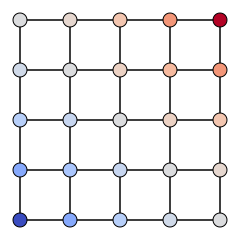

In [12]:
#### Display the solution to the Dirichlet problem with 1 hot source and 1 cold source, located on the opposite corners of the square
image = visualize_graph(adjacency, position, scores=temperatures, width=200, height=200)
SVG(image)

In [13]:
#### Add a hot source at the top-left corner of the sqaure.
dirichlet = Dirichlet()

bottom_left = 0
top_left = k-1
top_right = k * k - 1

values = {bottom_left: 0, top_right: 1, top_left: 1}

temperatures = dirichlet.fit_predict(adjacency, values=values)

#### What is the free node of highest temperature ?
highest_free_node = np.argsort(-temperatures)[2] # take index two because 0 and 1 are going to be the top left and right
print(f"The node of highest temperature is {highest_free_node}")

The node of highest temperature is 19


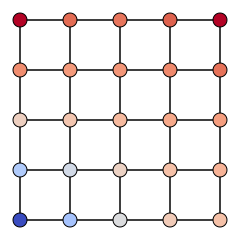

In [14]:
image = visualize_graph(adjacency, position, scores=temperatures, width=200, height=200)
SVG(image)

## Karate Club


We now consider the **classification** of nodes by heat diffusion. We use the [karate club graph](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) that has ground-truth labels.

In [15]:
dataset = karate_club(True)

In [16]:
adjacency = dataset.adjacency
position = dataset.position
labels_true = dataset.labels

In [17]:
n = len(labels_true)

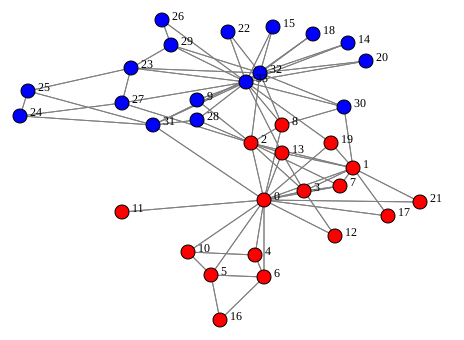

In [18]:
image = visualize_graph(adjacency, position, labels=labels_true, names=np.arange(n))
SVG(image)

## To do

* Select one node in each ground-truth cluster, and predict the labels of the other nodes by heat diffusion.
* Display the graph with the predicted labels.
* What is the accuracy of the classification?

## **Answer**

- The accuracy of the classification is 0.97.

In [19]:
 #### Select one node in each ground-truth cluster
labels_true = dataset.labels
labels = {0: labels_true[0], 26: labels_true[26]}
#### Predict the labels of the other nodes by heat diffusion
classifier = DiffusionClassifier()
labels_pred = classifier.fit_predict(adjacency, labels)

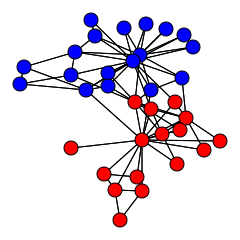

In [20]:
#### Display the graph with the predicted labels
image = visualize_graph(adjacency, position, labels=labels_pred, width=200, height=200)
SVG(image)

In [21]:
#### What is the accuracy of the classification ?
acc  = float(round(np.mean(labels_pred == labels_true), 2))
print(f"The accuracy of the classification is {acc}")

The accuracy of the classification is 0.97


## To do

The classifier applies temperature centering after diffusion.

* Repeat the same experiment without temperature centering.
* Do the same experiments with 3 nodes in a ground-truth cluster and 1 in the other.
* Comment the results.

## **Answers**

- Without temperature centering, we observe that node 0 from the red cluster dominates. This happens because it is a cetralized node with high degree.

- Unbalanced and centered scenario. In this scenario, we already achieve a much better division. The unbalance towards the blue cluster (nodes 26, 22 and 15) helps it to be more relevant, even though the chosen nodes are not centralized. Also, the centering technique penalizes the big red cluster and helps converting nodes to the blue cluster.

- Unbalanced and no centered scenario. The unbalance still helps blue nodes, but we can see that it only influentiates nodes that are nearby, since the three chosen nodes (26,22,15) are not centralized and also do not have a high degree. The blue cluster still has limited influence.

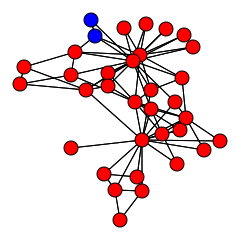

In [22]:
#### Repeat the same experiment without temperature centering
classifier_no_centering = DiffusionClassifier(centering=False)
labels = {0: labels_true[0], 26: labels_true[26]}
labels_pred_no_centering = classifier_no_centering.fit_predict(adjacency, labels)
image = visualize_graph(adjacency, position, labels=labels_pred_no_centering, width=200, height=200)
SVG(image)


In [23]:
acc_no_centering  = float(round(np.mean(labels_pred_no_centering == labels_true), 2))
print(f"The accuracy of the classification is {acc_no_centering}")

The accuracy of the classification is 0.56


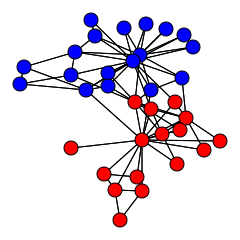

In [24]:
#### Do the same experiments with 3 nodes in a ground-truth cluster ans 1 in the other
  # centering scenario
classifier_unbalaced_centered = DiffusionClassifier(centering=True)
labels = {0: labels_true[0], 26: labels_true[26], 22: labels_true[22], 15:labels_true[15]}
labels_pred_unbalanced_centered = classifier_unbalaced_centered.fit_predict(adjacency, labels)
image = visualize_graph(adjacency, position, labels=labels_pred_unbalanced_centered, width=200, height=200)
SVG(image)


In [25]:
acc_unb_centered  = float(round(np.mean(labels_pred_unbalanced_centered == labels_true), 2))
print(f"The accuracy of the classification is {acc_unb_centered}")

The accuracy of the classification is 0.97


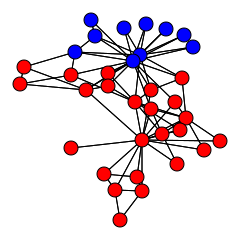

In [26]:
  # unbalanced and no centering scenario
classifier_unbalanced_nocentered = DiffusionClassifier(centering=False)
labels = {0: labels_true[0], 26: labels_true[26], 22: labels_true[22], 15:labels_true[15]}
labels_pred_unbalanced_nocentered = classifier_unbalanced_nocentered.fit_predict(adjacency, labels)
image = visualize_graph(adjacency, position, labels=labels_pred_unbalanced_nocentered, width=200, height=200)
SVG(image)


In [27]:
acc_unb_nocentered  = float(round(np.mean(labels_pred_unbalanced_nocentered == labels_true), 2))
print(f"The accuracy of the classification is {acc_unb_nocentered}")

The accuracy of the classification is 0.79


## Openflights


We now show how to classify the nodes of a graph **without labels**. We identify some nodes of interest and use these seeds to classify the other nodes.

In [28]:
dataset = openflights

In [29]:
adjacency = dataset.adjacency
position = dataset.position
names = dataset.names

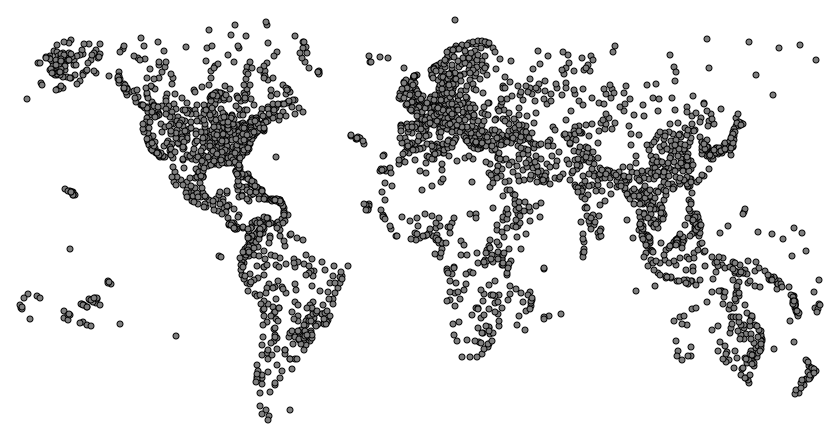

In [30]:
image = visualize_graph(adjacency, position, width=800, height=400, node_size=3, display_edges=False)
SVG(image)

## To do

* Display the same world map with the labels predicted for 3 seeds (Paris, New-York, Beijing), each with its own  label.
* Add Madrid with another label and comment the results.

#### **Answers**

- After adding Madrid, we observe that some nodes are converted to its cluster. Specially the nodes from South America, which are the Spanish speaking countries and is perfectly reasonable to see why they would be on Madrid's cluster.

In [31]:
paris = 622
newyork = 1842
beijing = 1618
madrid = 572

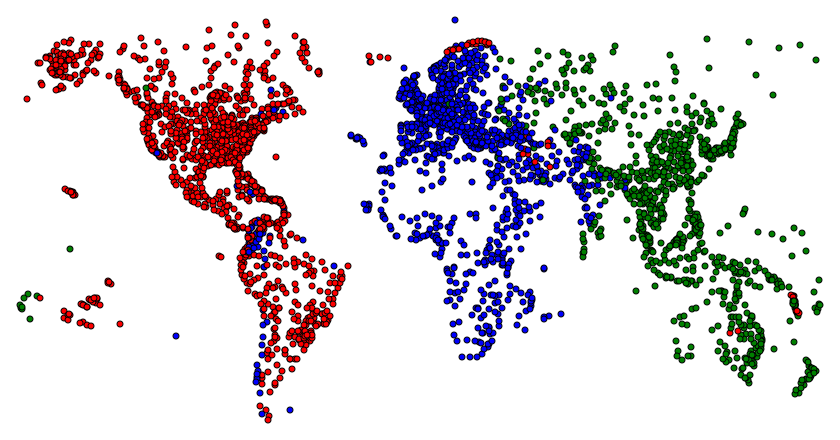

In [32]:
##### Display the same world map with the labels predicted for 3 seeds (Pairs, NewYork, Beijing) each with its own label
classifier = DiffusionClassifier()
labels = {paris: 0, newyork: 1, beijing: 2}
labels_pred = classifier.fit_predict(adjacency, labels)
image = visualize_graph(adjacency, position, labels=labels_pred, width=800, height=400, node_size=3, display_edges=False)
SVG(image)

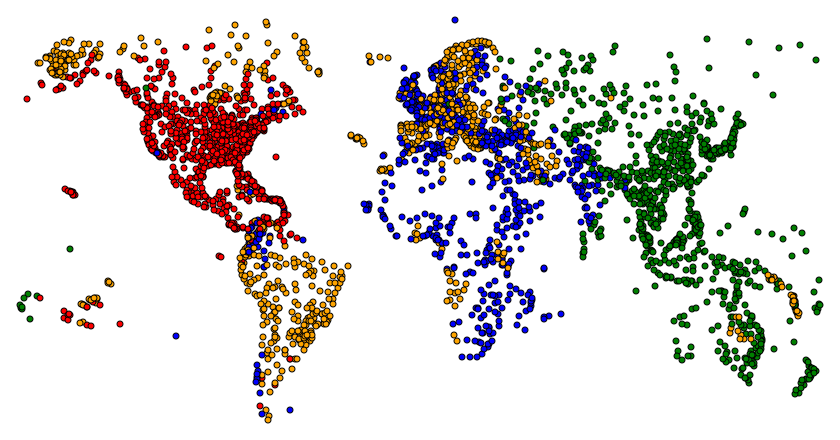

In [33]:
#  Add Madrid with another label .
classifier = DiffusionClassifier()
labels = {paris: 0, newyork: 1, beijing: 2, madrid: 3}
labels_pred = classifier.fit_predict(adjacency, labels)
image = visualize_graph(adjacency, position, labels=labels_pred, width=800, height=400, node_size=3, display_edges=False)
SVG(image)

Finally, we illustrate **contrastive ranking** on Openflights.

## To do

* List the top-10 airports that are the closest to Tokyo in terms of Personalized PageRank.
* List of the top-10 airports that are both the closest to Tokyo and the furthest from Paris Charles de Gaulle, using heat diffusion (contrastive ranking).<br>What do you observe?
* Give the temperatures of these airports after heat diffusion and explain the result.

#### **Answers**

- The top-10 airports that are both the closest to Tokyo and the furthest from Paris Charles de Gaulle are airports that are really close to Tokyo and are installed in medium/small japanese cities. It makes sense because, as small airports, they must not be world widely connected, which makes them distant to Paris Chales de Gaulle.

- It is also interesting to see that  the temperatures from these airports are 1.0, which adds more certainty to our hypothesis of none of these airports being connected at all to Charles de Gaule directly. Also, the proximity from the heat source Tokyo causes the high temperature.

In [34]:
tokyo = 1084

In [35]:
 # List the top-10 airports that are the closest to Tokyo in terms of Personalized PageRank.
pagerank = PageRank()


weights = np.zeros(adjacency.shape[0])
weights[tokyo] = 1

scores = pagerank.fit_predict(adjacency, weights=weights)

top_nodes = np.argsort(-scores)[:11]

for node in top_nodes:
    print(" ", names[node])

  Tokyo Haneda International Airport
  Incheon International Airport
  Naha Airport
  Taiwan Taoyuan International Airport
  Osaka International Airport
  Shanghai Pudong International Airport
  New Chitose Airport
  Kansai International Airport
  Narita International Airport
  Chubu Centrair International Airport
  Chek Lap Kok International Airport


In [36]:
#####  List of the top-10 airports that are both the closest to Tokyo and the furthest from Paris Charles de Gaulle,
#####  using heat diffusion (contrastive ranking).

classifier = Dirichlet()
labels = {paris: 0, tokyo: 1}

scores = classifier.fit_predict(adjacency, labels)


top10 = np.argsort(scores)[-11:][::-1]

print(names[top10])

['Tokachi-Obihiro Airport' 'Nanki Shirahama Airport'
 'Odate Noshiro Airport' 'Monbetsu Airport' 'Hachijojima Airport'
 'Tokyo Haneda International Airport' 'Oshima Airport' 'Noto Airport'
 'Tottori Airport' 'Tokushima Airport' 'Izumo Airport']


In [37]:
#### Give the temperature of these airports after heat diffusion and explain the results
for airport in top10:
  print(f"The temperatur of {names[airport]} is {scores[airport]}")

The temperatur of Tokachi-Obihiro Airport is 1.0
The temperatur of Nanki Shirahama Airport is 1.0
The temperatur of Odate Noshiro Airport is 1.0
The temperatur of Monbetsu Airport is 1.0
The temperatur of Hachijojima Airport is 1.0
The temperatur of Tokyo Haneda International Airport is 1.0
The temperatur of Oshima Airport is 1.0
The temperatur of Noto Airport is 1.0
The temperatur of Tottori Airport is 1.0
The temperatur of Tokushima Airport is 1.0
The temperatur of Izumo Airport is 1.0


## Wikipedia Vitals

We now consider the graph of links of WikiVitals, considered as undirected. We first focus on **constrastive ranking**, then on **node classification**.

In [38]:
dataset = wikivitals

In [39]:
adjacency = dataset.adjacency
names = dataset.names
labels = dataset.labels
names_labels = dataset.names_labels

In [40]:
adjacency = directed2undirected(adjacency)

## Contrastive ranking

## To do

* List the top-10 articles that are close to **Cat** and **Dog** in terms of Personalized PageRank.
* Compare with the list of top-10 articles that are close to **Cat** and **Dog** and far from **Bear** and **Tiger** using heat diffusion (contrastive ranking).
* List the top-10 articles that are close to **Bear** and **Tiger** and far from **Cat** and **Dog**. Comment the results.

#### **Answers**

- The list of articles close to cat and dog and far from bear and tiger are the breeds of cats and dogs, which are animals connected to the first two but far from the last two.

- The articles close to bear and tiger are the ones specifically connected to them, as "Winnie the poo". It follows the same logic as the last response.

In [41]:
# List the top-10 articles that are close to Cat and Dog in terms of Personalized Page Rank
pagerank = PageRank()

cat = np.where(names == "Cat")[0][0]
dog = np.where(names == "Dog")[0][0]

weights = np.zeros(len(names))

weights[cat] = 0.5
weights[dog] = 0.5

pagerank.fit(adjacency, weights=weights, force_bipartite=True)


scores = pagerank.fit_predict(adjacency, weights=weights)

top_nodes = np.argsort(-scores)

for node in top_nodes[:12]:
    print(names[node])

Dog
Cat
Animal
Mammal
Coyote
Lion
Pinniped
Brown bear
Tiger
Bear
Leopard
Carnivora


In [42]:
#####  Compare with the list of top-10 articles that are close to Cat and Dog and far from Bear and Tiger using heat diffusion (contrastive ranking).

bear = np.where(names == "Bear")[0][0]
tiger = np.where(names == "Tiger")[0][0]

classifier = Dirichlet()
labels2 = {cat: 1, dog: 1, bear: 0, tiger: 0}

scores = classifier.fit_predict(adjacency, labels2)


top10 = np.argsort(scores)[-12:][::-1]

for node in top10:
    print(names[node])

Cat
Dog
Domestic short-haired cat
Terrier
Retriever
Siamese cat
Great Dane
German Shepherd
Skink
Lyrebird
Pet
Budgerigar


In [43]:
##### List the top-10 articles that are close to Bear and Tiger and far from Cat and Dog. Comment the results.

classifier = Dirichlet()
labels2 = {cat: 0, dog: 0, bear: 1, tiger: 1}

scores = classifier.fit_predict(adjacency, labels2)


top10 = np.argsort(scores)[-11:][::-1]

for node in top10:
    print(names[node])

Tiger
Bear
Serranidae
Stuffed toy
Winnie-the-Pooh
Hibernation
Legendary creature
Shaving
Korean mythology
Mount St. Helens
Ursa Major


## Node classification

We now use the ground-truth labels provided by the category of each article.

In [44]:
print(names_labels)

['Arts' 'Biological and health sciences' 'Everyday life' 'Geography'
 'History' 'Mathematics' 'People' 'Philosophy and religion'
 'Physical sciences' 'Society and social sciences' 'Technology']


## To do

* What is the accuracy of node classification, using half of the nodes in the train set?
* Display the confusion matrix. What is the most difficult class to predict?
* Give examples of misclassification for each label (e.g., 2 false positives and 2 false negatives per label).

#### ** Answers **

- The most difficult class to predict is Peoplee, it was confused with geography.

In [45]:
#### What is the accuracy of node classification, using half of the nodes in the train set?

n = adjacency.shape[0]

rng = np.random.default_rng(0)
train_idx = rng.choice(n, size=n//2, replace=False)

labels_train = -np.ones(n)
labels_train[train_idx] = labels[train_idx]

classifier = DiffusionClassifier()

labels_pred = classifier.fit_predict(adjacency, labels_train)

accuracy = get_accuracy_score(labels, labels_pred)

test_mask = labels_train == -1

accuracy = get_accuracy_score(
    labels[test_mask],
    labels_pred[test_mask]
)

print(f"test acc {accuracy}")

test acc 0.7385137834598482


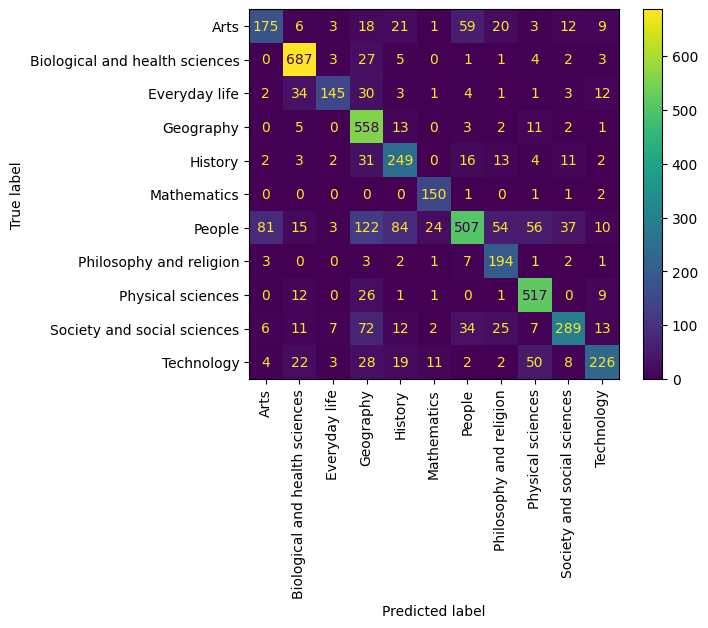

In [46]:
#### bDisplay the confusion matrix. What is the most difficult class to predict?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    labels[test_mask],
    labels_pred[test_mask]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=names_labels
)

disp.plot(xticks_rotation=90)
plt.show()

In [47]:
test_idx = np.where(test_mask)[0]

for c, class_name in enumerate(names_labels):
    print(f"\n{class_name}")

    # False negatives:
    fn = test_idx[(labels[test_mask] == c) &
                  (labels_pred[test_mask] != c)]

    print("False negatives:")
    for idx in fn[:2]:
        print(
            f"  {names[idx]} "
            f"(true={class_name}, "
            f"pred={names_labels[labels_pred[idx]]})"
        )

    # False positives:
    fp = test_idx[(labels[test_mask] != c) &
                  (labels_pred[test_mask] == c)]

    print("False positives:")
    for idx in fp[:2]:
        print(
            f"  {names[idx]} "
            f"(true={names_labels[labels[idx]]}, "
            f"pred={class_name})"
        )


Arts
False negatives:
  A Dictionary of the English Language (true=Arts, pred=People)
  Adventures of Huckleberry Finn (true=Arts, pred=People)
False positives:
  Action figure (true=Everyday life, pred=Arts)
  Alberto Giacometti (true=People, pred=Arts)

Biological and health sciences
False negatives:
  Adansonia (true=Biological and health sciences, pred=Geography)
  Agave (true=Biological and health sciences, pred=Everyday life)
False positives:
  Adolescence (true=Everyday life, pred=Biological and health sciences)
  Al-Zahrawi (true=People, pred=Biological and health sciences)

Everyday life
False negatives:
  Action figure (true=Everyday life, pred=Arts)
  Adolescence (true=Everyday life, pred=Biological and health sciences)
False positives:
  Agave (true=Biological and health sciences, pred=Everyday life)
  Alfred Kinsey (true=People, pred=Everyday life)

Geography
False negatives:
  Apennine Mountains (true=Geography, pred=History)
  Banc d'Arguin National Park (true=Geography

## To do

* Classify each article of the **People** category in one of the other categories (Mathematics, History, etc.), using all other labels.
* List the top-5 predicted people of each category using Personalized PageRank.

In [48]:
#### Classify each article of the People category in one of the other categories  using all other labels.
people_label = np.where(names_labels == "People")[0][0]

labels_train = labels.copy()
  # hide People labels
labels_train[labels == people_label] = -1

classifier = DiffusionClassifier()
labels_pred = classifier.fit_predict(adjacency, labels_train)

In [49]:
people_idx = np.where(labels == people_label)[0]

unique, counts = np.unique(labels_pred[people_idx], return_counts=True)

for label, count in zip(unique, counts):
    print(names_labels[label], count)

Arts 543
Biological and health sciences 34
Everyday life 21
Geography 344
History 384
Mathematics 42
Philosophy and religion 253
Physical sciences 110
Society and social sciences 224
Technology 36


In [50]:
#### List the top-5 predicted people of each category using Personalized PageRank.
pagerank = PageRank()

for c, category in enumerate(names_labels):
    if category == "People":
        continue

    # restart from all articles of category c
    seeds = np.where(labels == c)[0]

    weights = np.zeros(adjacency.shape[0])
    weights[seeds] = 1 / len(seeds)

    scores = pagerank.fit_predict(adjacency, weights=weights)

    # keep only People articles
    people_scores = scores[people_idx]

    top_people = people_idx[np.argsort(-people_scores)[:5]]

    print(f"\nTop5 People predicted as {category}:")
    for i in top_people:
        print(f"  {names[i]}")


Top5 People predicted as Arts:
  Aristotle
  Plato
  Ludwig van Beethoven
  Pablo Picasso
  Johann Sebastian Bach

Top5 People predicted as Biological and health sciences:
  Carl Linnaeus
  Aristotle
  Charles Darwin
  Pliny the Elder
  Plato

Top5 People predicted as Everyday life:
  Aristotle
  Plato
  Alexander the Great
  Augustine of Hippo
  Immanuel Kant

Top5 People predicted as Geography:
  Alexander the Great
  Aristotle
  Plato
  Winston Churchill
  Napoleon

Top5 People predicted as History:
  Alexander the Great
  Aristotle
  Plato
  Augustus
  Augustine of Hippo

Top5 People predicted as Mathematics:
  Leonhard Euler
  Carl Friedrich Gauss
  Gottfried Wilhelm Leibniz
  Bernhard Riemann
  John von Neumann

Top5 People predicted as Philosophy and religion:
  Augustine of Hippo
  Plato
  Aristotle
  Thomas Aquinas
  David Hume

Top5 People predicted as Physical sciences:
  Isaac Newton
  Albert Einstein
  Galileo Galilei
  Aristotle
  Leonhard Euler

Top5 People predicted as

## 2. Bipartite graphs

Finally, we consider the bipartite graph between articles and words in WikiVitals.

In [51]:
dataset = wikivitals
biadjacency = dataset.biadjacency

In [52]:
words = dataset.names_col

## To do

* Repeat the experiments on node classification using the bipartite graph between articles and words.
* Which information seems to be richer, the text or the hyperlinks between articles?
* Describe an approach that exploits both sources of information (no need to implement it).

## **Answer**
- The articles-link seems to be better because the accuracy is higher.

- Maybe if we combined both informations in a single graph it would be better.

In [53]:
##### repeat the experiments

  # What is the accuracy of node classification, using half of the nodes in the train set?


n = biadjacency.shape[0]

rng = np.random.default_rng(0)
train_idx = rng.choice(n, size=n//2, replace=False)

labels_train = -np.ones(n)
labels_train[train_idx] = labels[train_idx]

classifier = DiffusionClassifier()

labels_pred = classifier.fit_predict(biadjacency, labels_train)

test_mask = labels_train == -1

accuracy = get_accuracy_score(
    labels[test_mask],
    labels_pred[test_mask]
)

print(f"test acc {accuracy}")

test acc 0.7964442668797443


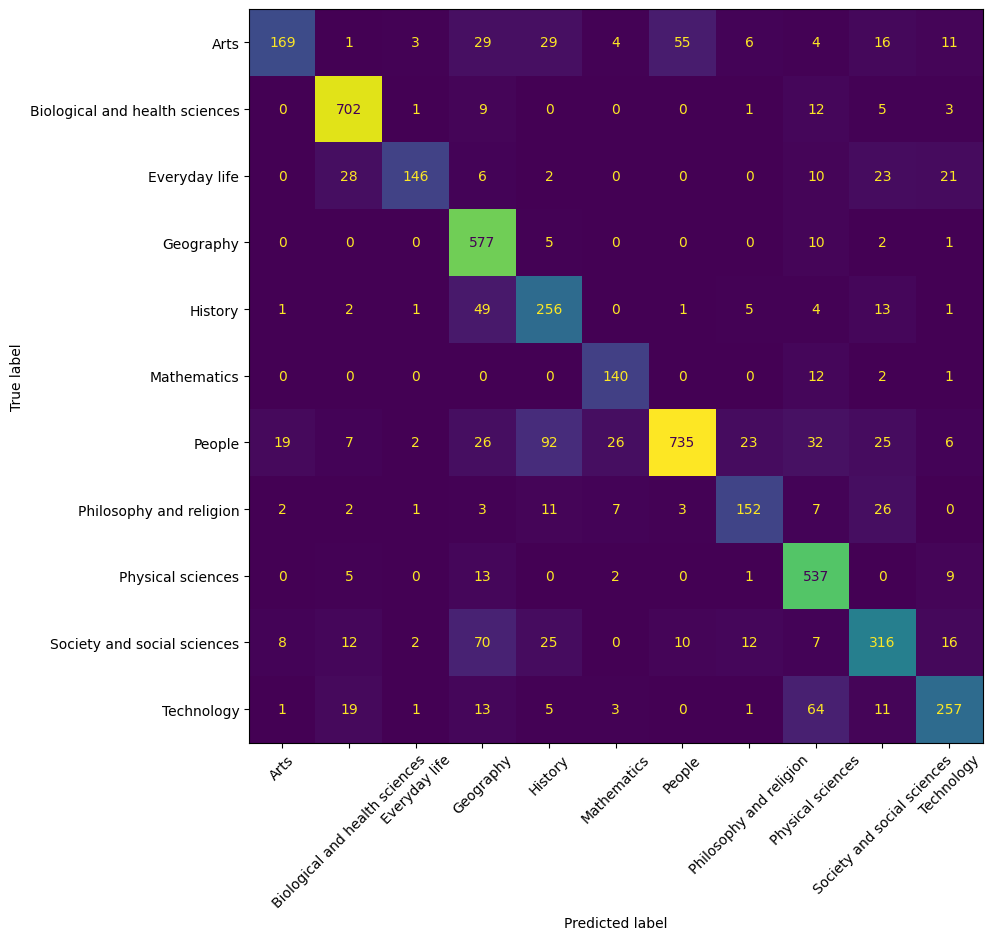

In [54]:
  # display confusion matrix

cm = confusion_matrix(labels[test_mask], labels_pred[test_mask])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=names_labels
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.tight_layout()
plt.show()

In [55]:
y_true = labels[test_mask]
y_pred = labels_pred[test_mask]
test_idx = np.where(test_mask)[0]

for c, class_name in enumerate(names_labels):

    print(f"\n {class_name} ")

    # False negatives
    fn_idx = np.where((y_true == c) & (y_pred != c))[0]

    print("False negatives:")
    for k in fn_idx[:2]:
        node = test_idx[k]
        print(
            f"  {names[node]}"
            f" (predicted {names_labels[y_pred[k]]})"
        )

    if len(fn_idx) == 0:
        print("  None")

    # False positives
    fp_idx = np.where((y_true != c) & (y_pred == c))[0]

    print("False positives:")
    for k in fp_idx[:2]:
        node = test_idx[k]
        print(
            f"  {names[node]}"
            f" (true label: {names_labels[y_true[k]]})"
        )

    if len(fp_idx) == 0:
        print("  None")


 Arts 
False negatives:
  8½ (predicted People)
  A Dictionary of the English Language (predicted People)
False positives:
  Aeschylus (true label: People)
  Alvar Aalto (true label: People)

 Biological and health sciences 
False negatives:
  Alkaloid (predicted Physical sciences)
  American Brahman (predicted Geography)
False positives:
  Agriculture (true label: Society and social sciences)
  Amnesia (true label: Society and social sciences)

 Everyday life 
False negatives:
  Adolescence (predicted Society and social sciences)
  Adult (predicted Society and social sciences)
False positives:
  Club (organization) (true label: Society and social sciences)
  Club (weapon) (true label: Technology)

 Geography 
False negatives:
  Antarctic Circle (predicted Physical sciences)
  Crimea (predicted History)
False positives:
  1556 Shaanxi earthquake (true label: History)
  1970 Bhola cyclone (true label: History)

 History 
False negatives:
  1556 Shaanxi earthquake (predicted Geography)
